In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
import matplotlib.pyplot as plt
import warnings
from math import prod

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load the dataset
# Replace the file path with your actual path
data = pd.read_excel("class1_dataset.xlsx")

# Extract the predictors and outcome
X = data.drop('RRI', axis=1)
Y = data['RRI']

# Define the feature indexes to be used as predictors
# Note: Pandas uses 0-based indexing
feature_indexes = [24, 20, 16, 38, 15, 12, 3, 10, 13, 21, 9, 22, 19, 26, 28, 33, 2, 29, 6, 5, 35, 32, 30, 11, 31, 25, 8, 1, 23, 37, 27, 14, 0, 4, 18, 17, 36]

# Select the specified features using .iloc
X_selected = X.iloc[:, feature_indexes]

# Define the oversampling strategies
samplers = [
    ('random_over', RandomOverSampler()),
    ('smote', SMOTE()),
    ('adasyn', ADASYN())
]

# Initialize the Support Vector Classifier with probability estimates enabled
svm_classifier = SVC(probability=True, random_state=42)

# Create the pipeline with sampler and classifier
pipeline = ImbPipeline([
    ('sampler', RandomOverSampler()),  # Placeholder, will be set in GridSearchCV
    ('classifier', svm_classifier)
])

# Define the parameter grid for hyperparameter tuning
param_grid = [
    {
        'sampler': [RandomOverSampler(), SMOTE(), ADASYN()],
        'sampler__sampling_strategy': ['auto', 0.5, 0.75],
        'classifier__kernel': ['linear'],
        'classifier__C': [50, 100, 150],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__tol': [1e-3, 1e-4],
        'classifier__max_iter': [10000]  # Set max_iter values for linear kernel
    },
    {
        'sampler': [RandomOverSampler(), SMOTE(), ADASYN()],
        'sampler__sampling_strategy': ['auto', 0.5, 0.75],
        'classifier__kernel': ['rbf'],
        'classifier__C': [50, 100, 150],
        'classifier__gamma': ['scale', 'auto', 1e-2, 1e-3],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__tol': [1e-3, 1e-4],
        'classifier__max_iter': [10000]  # Set max_iter values for rbf kernel
    },
    {
        'sampler': [RandomOverSampler(), SMOTE(), ADASYN()],
        'sampler__sampling_strategy': ['auto', 0.5, 0.75],
        'classifier__kernel': ['poly'],
        'classifier__C': [50, 100, 150],
        'classifier__gamma': ['scale', 'auto'],
        'classifier__degree': [2, 3, 4],
        'classifier__coef0': [0.0, 0.1, 0.5],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__tol': [1e-3, 1e-4],
        'classifier__max_iter': [10000]  # Set max_iter values for poly kernel
    }
]

# Define the scoring metrics
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'f1': 'f1'
}

# Define the Stratified 10-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Compute the exact number of combinations (optional)
n_param_combinations = sum([prod([len(v) for v in d.values()]) for d in param_grid])

# Initialize Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # Use 'roc_auc' to select the best model
    cv=cv,
    n_jobs=-1,  # Use all available cores
    verbose=0,  # Disable sklearn's verbose
    return_train_score=False
)

# Fit the Grid Search to the data without progress bar
print("Starting Grid Search...")
grid_search.fit(X_selected, Y)
print("Grid Search Completed.")

# Retrieve the best average AUC and its standard deviation
best_auc = grid_search.best_score_
# Retrieve the standard deviation from cv_results_
# Identify the index of the best parameter set
best_index = grid_search.best_index_
best_auc_std = grid_search.cv_results_['std_test_roc_auc'][best_index]

# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Retrieve the other metrics for the best parameter set
best_accuracy = grid_search.cv_results_['mean_test_accuracy'][best_index]
best_accuracy_std = grid_search.cv_results_['std_test_accuracy'][best_index]

best_precision = grid_search.cv_results_['mean_test_precision'][best_index]
best_precision_std = grid_search.cv_results_['std_test_precision'][best_index]

best_f1 = grid_search.cv_results_['mean_test_f1'][best_index]
best_f1_std = grid_search.cv_results_['std_test_f1'][best_index]

# Output the results
print(f"\nBest Average AUC: {best_auc:.4f} ± {best_auc_std:.4f}")
print(f"Average Accuracy: {best_accuracy:.4f} ± {best_accuracy_std:.4f}")
print(f"Average Precision: {best_precision:.4f} ± {best_precision_std:.4f}")
print(f"Average F1 Score: {best_f1:.4f} ± {best_f1_std:.4f}")
print("\nBest Hyperparameters:")
for param, value in best_params.items():
    if isinstance(value, (SMOTE, ADASYN, RandomOverSampler)):
        print(f"  {param}: {value.__class__.__name__}")
    else:
        print(f"  {param}: {value}")

Starting Grid Search...
Grid Search Completed.

Best Average AUC: 0.7269 ± 0.0284
Average Accuracy: 0.7397 ± 0.0112
Average Precision: 0.1927 ± 0.0115
Average F1 Score: 0.2891 ± 0.0160

Best Hyperparameters:
  classifier__C: 100
  classifier__class_weight: None
  classifier__gamma: scale
  classifier__kernel: rbf
  classifier__max_iter: 10000
  classifier__tol: 0.001
  sampler: RandomOverSampler
  sampler__sampling_strategy: auto


In [2]:
# Retrieve the best estimator from Grid Search
best_estimator = grid_search.best_estimator_

# Use cross_val_predict to get cross-validated predicted probabilities
# Setting method='predict_proba' and using cv to ensure consistency
print("\nGenerating cross-validated predicted probabilities...")
y_pred_proba = cross_val_predict(best_estimator, X_selected, Y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

# Define a range of threshold values to evaluate
thresholds = np.linspace(0.0, 1.0, 101)

# Initialize variables to store the best metrics and threshold
best_threshold = 0.5
best_f1_score = 0.0
best_accuracy = 0.0
best_precision = 0.0

print("Optimizing threshold to maximize F1 score...")

for threshold in thresholds:
    # Convert predicted probabilities to binary predictions based on the threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Calculate F1 score
    current_f1 = f1_score(Y, y_pred)
    
    # Update the best metrics and threshold if current F1 is better
    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        best_threshold = threshold
        best_accuracy = accuracy_score(Y, y_pred)
        best_precision = precision_score(Y, y_pred, zero_division=0)

# Calculate standard deviations using cross-validation
# To compute standard deviations, we'll perform cross-validation predictions and calculate metrics at the best threshold

# Initialize lists to store per-fold metrics
f1_scores = []
accuracies = []
precisions = []

print("\nCalculating metrics at the optimal threshold across folds...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_selected, Y), 1):
    # Split data
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
    # Fit the model on the training data
    best_estimator.fit(X_train, y_train)
    
    # Predict probabilities on the test data
    y_proba_fold = best_estimator.predict_proba(X_test)[:, 1]
    
    # Apply the optimal threshold
    y_pred_fold = (y_proba_fold >= best_threshold).astype(int)
    
    # Calculate metrics
    fold_f1 = f1_score(y_test, y_pred_fold)
    fold_accuracy = accuracy_score(y_test, y_pred_fold)
    fold_precision = precision_score(y_test, y_pred_fold, zero_division=0)
    
    # Append to lists
    f1_scores.append(fold_f1)
    accuracies.append(fold_accuracy)
    precisions.append(fold_precision)
    
    print(f"  Fold {fold}: F1={fold_f1:.4f}, Accuracy={fold_accuracy:.4f}, Precision={fold_precision:.4f}")

# Calculate mean and standard deviation for the metrics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

mean_precision = np.mean(precisions)
std_precision = np.std(precisions)

# Output the optimized threshold and corresponding metrics
print(f"\n=== Optimized Threshold ===")
print(f"Threshold for Maximum F1 Score: {best_threshold:.2f}")

print(f"\n=== Metrics at Optimal Threshold ===")
print(f"F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")
print(f"Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Precision: {mean_precision:.4f} ± {std_precision:.4f}")


Generating cross-validated predicted probabilities...
Optimizing threshold to maximize F1 score...

Calculating metrics at the optimal threshold across folds...
  Fold 1: F1=0.3247, Accuracy=0.8320, Precision=0.2577
  Fold 2: F1=0.3407, Accuracy=0.8560, Precision=0.2911
  Fold 3: F1=0.2727, Accuracy=0.8447, Precision=0.2368
  Fold 4: F1=0.2687, Accuracy=0.8414, Precision=0.2308
  Fold 5: F1=0.2394, Accuracy=0.8252, Precision=0.1977
  Fold 6: F1=0.2695, Accuracy=0.8333, Precision=0.2235
  Fold 7: F1=0.3056, Accuracy=0.8382, Precision=0.2500
  Fold 8: F1=0.3022, Accuracy=0.8430, Precision=0.2561
  Fold 9: F1=0.3284, Accuracy=0.8544, Precision=0.2857
  Fold 10: F1=0.2923, Accuracy=0.8511, Precision=0.2603

=== Optimized Threshold ===
Threshold for Maximum F1 Score: 0.76

=== Metrics at Optimal Threshold ===
F1 Score: 0.2944 ± 0.0303
Accuracy: 0.8419 ± 0.0095
Precision: 0.2490 ± 0.0267


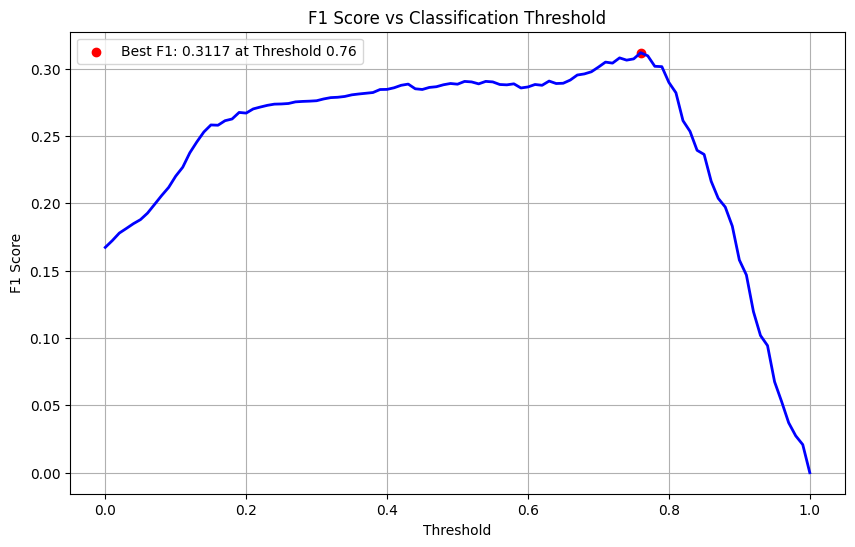

In [3]:
# Plot F1 Score vs Threshold
f1_scores_plot = []
for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(Y, y_pred)
    f1_scores_plot.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_plot, color='blue', lw=2)
plt.scatter(best_threshold, best_f1_score, color='red', 
            label=f'Best F1: {best_f1_score:.4f} at Threshold {best_threshold:.2f}')
plt.title('F1 Score vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Shut down the virtual machine (Linux-based command)
# import os
# print("Shutting down the VM...")
# password = "Henryjesson123"  # Replace this with the actual password
# os.system(f'echo {password} | sudo -S shutdown -h now')